# R2Gen-KG: Training & Testing on IU X-Ray

This notebook trains the R2Gen model with Knowledge Graph (KG) and Contrastive Attention (CA) on the IU X-Ray dataset, then evaluates on the test split.

**Pipeline:**
1. Setup environment & args
2. Load tokenizer and dataloaders
3. Build model (auto-constructs KG during init)
4. Build contrastive attention normality pool
5. Stage 1 — KG pretraining (optional)
6. Stage 2 — Full report generation training
7. Evaluation on test set

## 1. Imports & Environment

In [1]:
!python --version

Python 3.12.13


In [2]:
!nvidia-smi

Mon Apr 20 13:00:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os, sys
from pathlib import Path

!git clone https://github.com/thimaianhphan/thesis.git /content/R2Gen-main

REPO_ROOT = Path("/content/R2Gen-main")
# ─────────────────────────────────────────────────────────────────────────────

import json, random, argparse
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root : {REPO_ROOT}")
print(f"CWD       : {os.getcwd()}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")

Cloning into '/content/R2Gen-main'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 131 (delta 37), reused 48 (delta 21), pack-reused 65 (from 1)
Receiving objects: 100% (131/131), 71.18 MiB | 17.30 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Repo root : /content/R2Gen-main
CWD       : /content/R2Gen-main
PyTorch   : 2.10.0+cu128
CUDA      : True
GPU       : NVIDIA L4


In [ ]:
# ── hyperparameters ───────────────────────────────────────────────────────────
# Use argparse.Namespace so existing modules accept the config unchanged.

_device_str = "cuda" if torch.cuda.is_available() else "cpu"

args = argparse.Namespace(
    # ── paths ──────────────────────────────────────────────────────────────
    image_dir       = "data/iu_xray/images/",
    ann_path        = "data/iu_xray/annotation.json",
    dataset_name    = "iu_xray",
    save_dir        = "results/iu_xray_kg",

    # ── tokeniser ──────────────────────────────────────────────────────────
    max_seq_length  = 60,
    threshold       = 3,

    # ── data loading ───────────────────────────────────────────────────────
    batch_size      = 16,
    num_workers     = 2,

    # ── visual extractor ───────────────────────────────────────────────────
    visual_extractor            = "resnet101",
    visual_extractor_pretrained = True,
    d_vf                        = 2048,

    # ── transformer ────────────────────────────────────────────────────────
    d_model         = 512,
    d_ff            = 512,
    num_heads       = 8,
    num_layers      = 3,
    dropout         = 0.1,
    drop_prob_lm    = 0.5,

    # ── decoding ───────────────────────────────────────────────────────────
    sample_method       = "beam_search",
    beam_size           = 3,
    temperature         = 1.0,
    sample_n            = 1,
    group_size          = 1,
    output_logsoftmax   = 1,
    decoding_constraint = 0,
    block_trigrams      = 1,

    # ── knowledge graph ────────────────────────────────────────────────────
    kg_max_nodes          = 40,
    kg_min_term_freq      = 5,
    kg_co_occur_threshold = 3,
    kg_pretrain_epochs    = 10,
    kg_loss_weight        = 0.1,
    biomedclip_device     = _device_str,   # auto: cuda if available

    # ── contrastive attention ──────────────────────────────────────────────
    use_contrastive_attention = True,
    ca_pool_size              = 100,
    ca_num_rounds             = 3,
    ca_dropout                = 0.1,

    # ── optimiser ──────────────────────────────────────────────────────────
    optim        = "Adam",
    lr_ve        = 5e-5,
    lr_ed        = 1e-4,
    weight_decay = 5e-5,
    amsgrad      = True,
    adam_betas   = (0.9, 0.98),
    adam_eps     = 1e-9,

    # ── LR scheduler ───────────────────────────────────────────────────────
    lr_scheduler = "StepLR",
    step_size    = 50,
    gamma        = 0.1,

    # ── training ───────────────────────────────────────────────────────────
    epochs         = 100,
    save_period    = 1,
    monitor_metric = "val_BLEU_4",
    monitor_mode   = "max",
    early_stop     = 50,
    seed           = SEED,
    resume         = None,
)

if args.visual_extractor == "medsam":
    args.d_vf = 256

os.makedirs(args.save_dir, exist_ok=True)
print("Config ready. save_dir:", args.save_dir)
print("biomedclip_device:", args.biomedclip_device)

In [20]:
import os

os.chdir('/content/R2Gen-main')
print(f"Current working directory: {os.getcwd()}")

!mv data/iu_xray/iu_xray/images data/iu_xray/images/
!mv data/iu_xray/iu_xray/annotation.json data/iu_xray/
!rm -r data/iu_xray/iu_xray/

Current working directory: /content/R2Gen-main


## 2. Configuration

In [6]:
# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 9233
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# ── hyperparameters ───────────────────────────────────────────────────────────
# Use argparse.Namespace so existing modules accept the config unchanged.

args = argparse.Namespace(
    # ── paths ──────────────────────────────────────────────────────────────
    image_dir       = "data/iu_xray/images/",
    ann_path        = "data/iu_xray/annotation.json",
    dataset_name    = "iu_xray",
    save_dir        = "results/iu_xray_kg",

    # ── tokeniser ──────────────────────────────────────────────────────────
    max_seq_length  = 60,
    threshold       = 3,       # min token frequency to include in vocab

    # ── data loading ───────────────────────────────────────────────────────
    batch_size      = 16,
    num_workers     = 8,       # set >0 if your OS supports shared memory

    # ── visual extractor ───────────────────────────────────────────────────
    # Options: 'resnet101'  →  d_vf=2048
    #          'medsam'     →  d_vf=256
    visual_extractor           = "resnet50",
    visual_extractor_pretrained = True,
    d_vf                       = 2048,

    # ── transformer ────────────────────────────────────────────────────────
    d_model         = 512,
    d_ff            = 512,
    num_heads       = 8,
    num_layers      = 3,
    dropout         = 0.1,
    drop_prob_lm    = 0.5,

    # ── decoding ───────────────────────────────────────────────────────────
    sample_method   = "beam_search",
    beam_size       = 3,
    temperature     = 1.0,
    sample_n        = 1,
    group_size      = 1,
    output_logsoftmax = 1,
    decoding_constraint = 0,
    block_trigrams  = 1,

    # ── knowledge graph ────────────────────────────────────────────────────
    kg_min_term_freq       = 5,
    kg_co_occur_threshold  = 3,
    kg_pretrain_epochs     = 10,
    kg_loss_weight         = 0.1,
    biomedclip_device      = "cuda",   # change to 'cuda' if VRAM allows

    # ── contrastive attention ──────────────────────────────────────────────
    use_contrastive_attention = True,
    ca_pool_size              = 100,
    ca_num_rounds             = 3,
    ca_dropout                = 0.1,

    # ── optimiser ──────────────────────────────────────────────────────────
    optim           = "Adam",
    lr_ve           = 5e-5,    # visual extractor learning rate
    lr_ed           = 1e-4,    # encoder-decoder learning rate
    weight_decay    = 5e-5,
    amsgrad         = True,
    adam_betas      = (0.9, 0.98),
    adam_eps        = 1e-9,

    # ── LR scheduler ───────────────────────────────────────────────────────
    lr_scheduler    = "StepLR",
    step_size       = 50,
    gamma           = 0.1,

    # ── training ───────────────────────────────────────────────────────────
    epochs          = 100,
    save_period     = 1,
    monitor_metric  = "val_BLEU_4",
    monitor_mode    = "max",
    early_stop      = 50,
    seed            = SEED,
    resume          = None,    # path to checkpoint to resume from
)

# Auto-set d_vf if you switch visual_extractor to medsam
if args.visual_extractor == "medsam":
    args.d_vf = 256

os.makedirs(args.save_dir, exist_ok=True)
print("Config ready. save_dir:", args.save_dir)

Config ready. save_dir: results/iu_xray_kg


## 3. Inspect Dataset

In [24]:
with open(args.ann_path) as f:
    annotation = json.load(f)

for split in ("train", "val", "test"):
    print(f"{split:5s}: {len(annotation[split]):4d} studies")

# Preview one example
sample = annotation["train"][0]
print("\nSample keys:", list(sample.keys()))
print("Report:", sample["report"][:120], "...")
print("Images:", sample["image_path"])

train: 2069 studies
val  :  296 studies
test :  590 studies

Sample keys: ['id', 'report', 'image_path', 'split']
Report: The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free ...
Images: ['CXR2384_IM-0942/0.png', 'CXR2384_IM-0942/1.png']


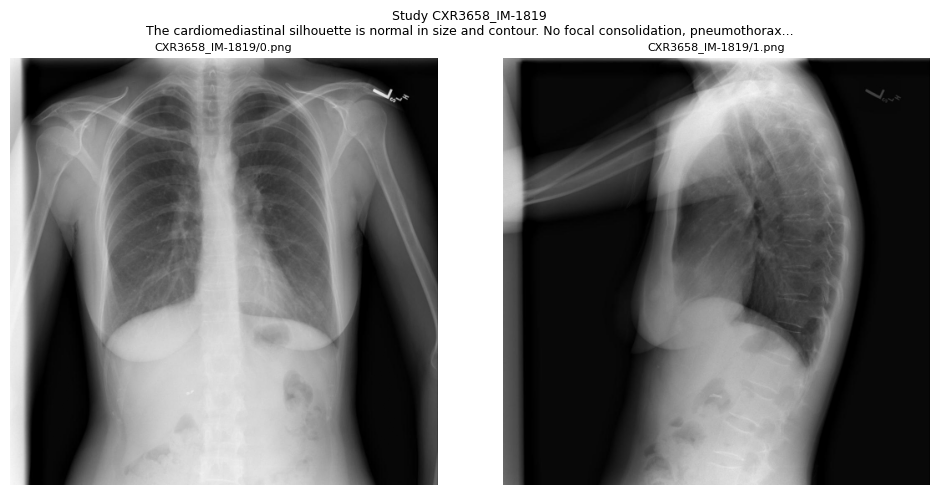

In [25]:
# Visual spot-check — show the two X-rays for a random study
idx = random.randint(0, len(annotation["train"]) - 1)
sample = annotation["train"][idx]
fig, axes = plt.subplots(1, len(sample["image_path"]), figsize=(10, 5))
if len(sample["image_path"]) == 1:
    axes = [axes]
for ax, img_rel in zip(axes, sample["image_path"]):
    img_path = os.path.join(args.image_dir, img_rel)
    ax.imshow(mpimg.imread(img_path), cmap="gray")
    ax.set_title(img_rel, fontsize=8)
    ax.axis("off")
fig.suptitle(f"Study {sample['id']}\n{sample['report'][:100]}...", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Tokenizer & Dataloaders

In [8]:
from modules.tokenizers import Tokenizer
from modules.dataloaders import R2DataLoader

tokenizer = Tokenizer(args)
print(f"Vocabulary size: {tokenizer.get_vocab_size()}")

Vocabulary size: 760


In [9]:
train_dataloader = R2DataLoader(args, tokenizer, split="train", shuffle=True)
val_dataloader   = R2DataLoader(args, tokenizer, split="val",   shuffle=False)
test_dataloader  = R2DataLoader(args, tokenizer, split="test",  shuffle=False)

print(f"Train batches : {len(train_dataloader)}")
print(f"Val batches   : {len(val_dataloader)}")
print(f"Test batches  : {len(test_dataloader)}")

# Sanity-check one batch shape
ids, images, reports_ids, reports_masks = next(iter(train_dataloader))
print(f"\nImages shape  : {images.shape}   # [B, 2, 3, H, W]")
print(f"Reports shape : {reports_ids.shape}  # [B, L]")

Train batches : 130
Val batches   : 19
Test batches  : 37

Images shape  : torch.Size([16, 2, 3, 224, 224])   # [B, 2, 3, H, W]
Reports shape : torch.Size([16, 60])  # [B, L]


In [11]:

import os

os.chdir('/content/R2Gen-main')
print(f"Current working directory: {os.getcwd()}")

!python main_train_kg.py \
    --image_dir data/iu_xray/images/ \
    --ann_path data/iu_xray/annotation.json \
    --dataset_name iu_xray \
    --max_seq_length 60 \
    --visual_extractor resnet50 \
    --num_workers 8 \
    --threshold 3 \
    --batch_size 16 \
    --epochs 80 \
    --save_dir results/iu_xray_kg \
    --step_size 40 \
    --gamma 0.1 \
    --seed 9223 \
    \
    --kg_num_gcn_layers 1 \
    --kg_gcn_alpha 0.2 \
    --kg_loss_weight 0.1 \
    --kg_pretrain_epochs 20 \
    --kg_pretrain_lr 1e-4 \
    --kg_co_occur_threshold 3 \
    --use_contrastive_attention \
    --ca_pool_size 100 \
    --ca_num_rounds 3

Current working directory: /content/R2Gen-main
[Main] Device: cuda:0
[Main] Visual extractor : resnet50  (d_vf=2048)
[Main] BiomedCLIP device: cpu
[Main] Contrastive Attn : True
Traceback (most recent call last):
  File "/content/R2Gen-main/main_train_kg.py", line 335, in <module>
    main()
  File "/content/R2Gen-main/main_train_kg.py", line 305, in main
    model = R2GenKGModel(args, tokenizer)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/R2Gen-main/models/r2gen_kg.py", line 18, in __init__
    self.visual_extractor = VisualExtractor(args)
                            ^^^^^^^^^^^^^^^^^^^^^
  File "/content/R2Gen-main/modules/visual_extractor.py", line 177, in __init__
    self.extractor = ResNetVisualExtractor(args)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/R2Gen-main/modules/visual_extractor.py", line 142, in __init__
    model = getattr(models, self.visual_extractor)(pretrained=self.pretrained)
                    ^^^^^^
NameError: name 'models'

In [ ]:
import os

os.chdir('/content/R2Gen-main')
print(f"Current working directory: {os.getcwd()}")

!python main_test_kg.py \
    --image_dir data/iu_xray/images/ \
    --ann_path data/iu_xray/annotation.json \
    --dataset_name iu_xray \
    --max_seq_length 60 \
    --threshold 3 \
    --batch_size 16 \
    --num_workers 8 \
    --save_dir results/iu_xray_kg \
    --seed 9223 \
    --visual_extractor resnet50 \
    --epochs 70 \
    --step_size 35 \
    \
    --kg_num_gcn_layers 1 \
    --kg_gcn_alpha 0.2 \
    --kg_loss_weight 0.1 \
    --kg_pretrain_epochs 10 \
    --kg_pretrain_lr 1e-4 \
    --kg_co_occur_threshold 3 \
    \
    --use_contrastive_attention \
    --ca_pool_size 100 \
    --ca_num_rounds 3 \
    \
    --load results/iu_xray_kg/model_best.pth